In [8]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap


df_interactions = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/cropped_interactions.csv')

df_cluster = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/F15_KMAX3_DMAX4_NMIN1500--/pca-data3-F15-mcmodels4-Kmax3-Dmax4-Nmin1500-05-2026.csv')

df =  pd.merge(
            df_interactions, 
            df_cluster[['interaction_id', 'Yhat.idt.pca']], 
            on='interaction_id', 
            how='inner'
        )         


### FIGURE 1 EXAMPLE INTERACTIONS

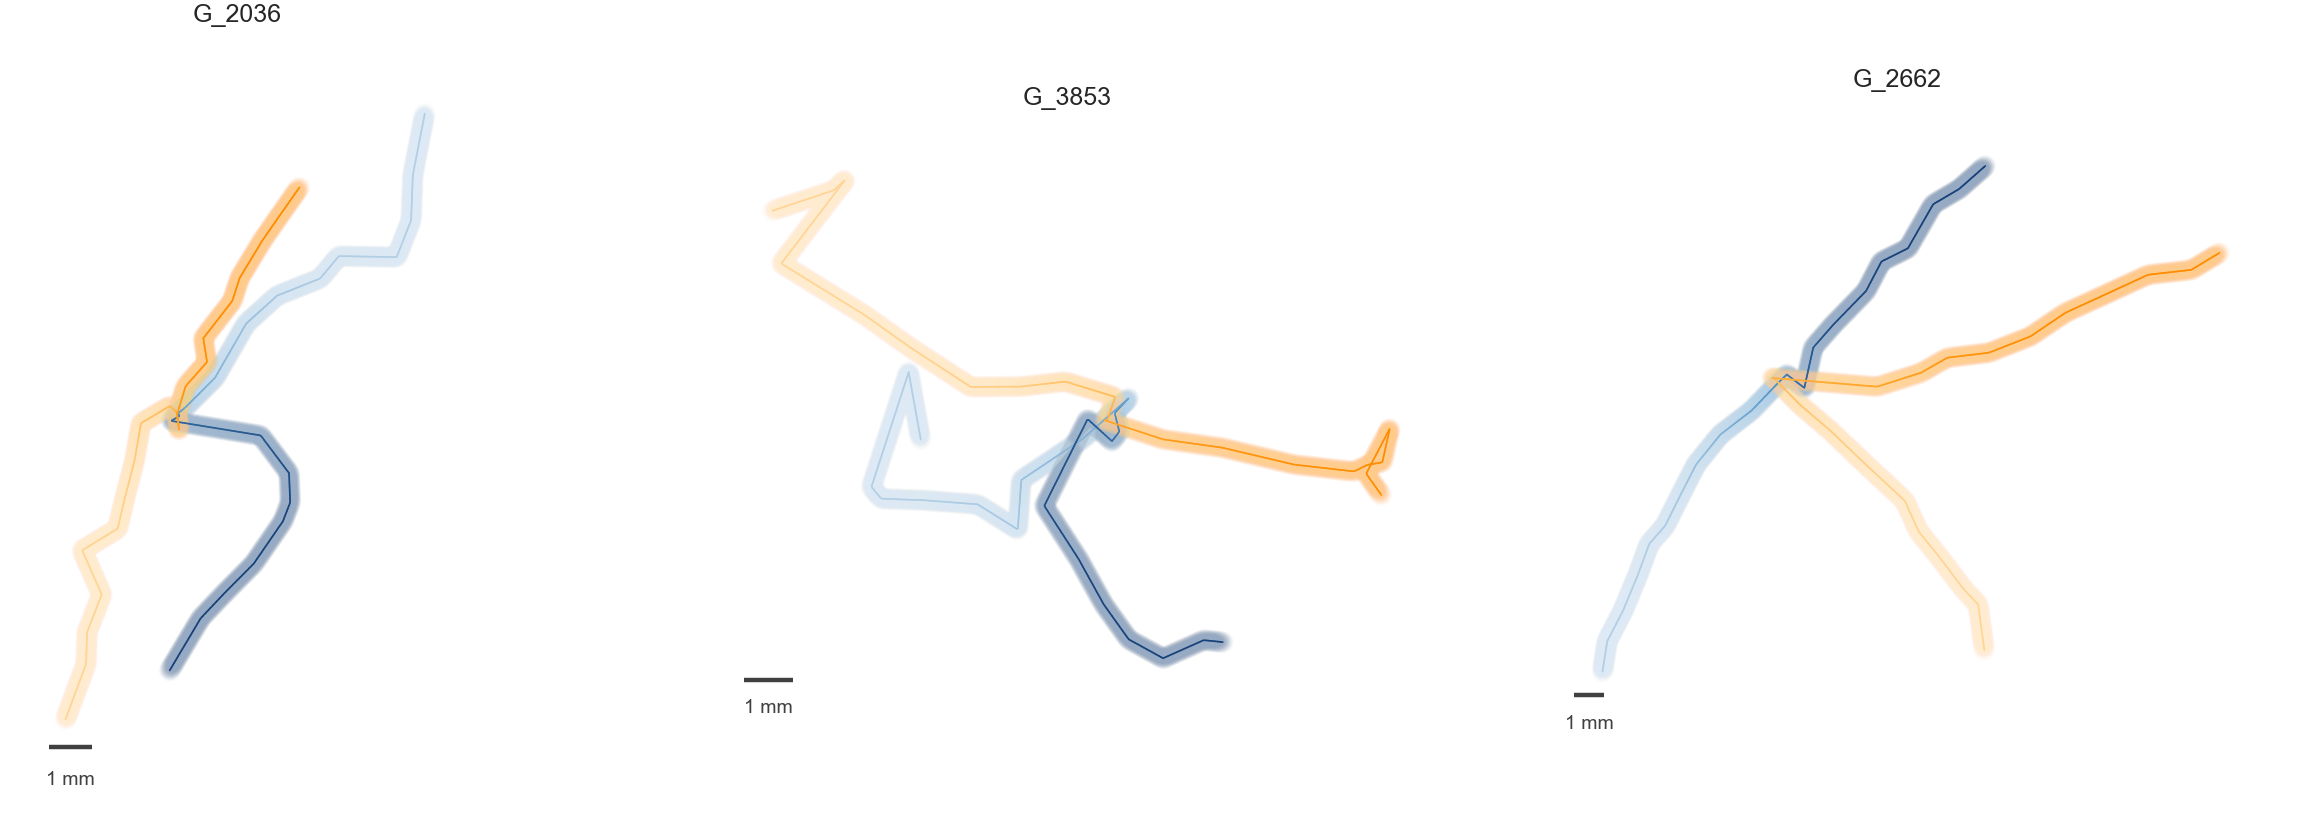

In [9]:
## FIGURE TRACES: THIN HEAD LINE WITH A SOFT BAND AROUND IT

IDS = ['G_2036', 'G_3853', 'G_2662']
NODE = 'head'
CORE_LW = 0.6            # thin saturated line
HALO_W = 8               # widest layer of the soft band
N_HALO = 16              # layers -- more layers, softer falloff
HALO_ALPHA = 0.045       # per layer; they stack toward the centre
HALO_TINT = 0.55         # 0 = same colour, 1 = white
N_INTERP = 400
CLIP = (0.0, 1.0)        # start pale, end saturated
CONTRAST = 3.0           # 1 = linear ramp; higher = more of the trace sits at the extremes
SCALE_BAR_MM = 1

mpl.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42,
                     'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

CMAPS = {1: LinearSegmentedColormap.from_list('t1', ['#b3cfe6', '#4e93c6', '#17427a']),
         2: LinearSegmentedColormap.from_list('t2', ['#ffd596', '#ffb03a', '#ff8c00'])}


def resample(pts, n=N_INTERP):
    d = np.r_[0, np.cumsum(np.linalg.norm(np.diff(pts, axis=0), axis=1))]
    s = np.linspace(0, d[-1], n)
    xy = np.column_stack([np.interp(s, d, pts[:, 0]), np.interp(s, d, pts[:, 1])])
    t = np.interp(s, d, np.linspace(0, 1, len(pts)))
    return xy, t


def ramp(t, contrast=CONTRAST):
    """S-curve on time: holds near the pale and dark ends, flips quickly in between"""
    t = np.clip(t, 0, 1)
    s = t ** contrast / (t ** contrast + (1 - t) ** contrast + 1e-12)
    return CLIP[0] + s * (CLIP[1] - CLIP[0])


def lighten(cols, f=HALO_TINT):
    out = cols.copy()
    out[:, :3] = out[:, :3] + (1 - out[:, :3]) * f
    return out


def trace(ax, ex, tr):
    pts = ex[[f'mm_Track_{tr} x_{NODE}', f'mm_Track_{tr} y_{NODE}']].values
    xy, t = resample(pts)
    segs = np.stack([xy[:-1], xy[1:]], axis=1)
    cols = CMAPS[tr](ramp(t[:-1]))
    pale = lighten(cols)

    for w in np.linspace(HALO_W, CORE_LW * 1.5, N_HALO):
        ax.add_collection(LineCollection(segs, colors=pale, linewidths=w,
                                         alpha=HALO_ALPHA, capstyle='round',
                                         joinstyle='round', zorder=2))
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=CORE_LW,
                                     capstyle='round', joinstyle='round', zorder=3))
    ax.plot(xy[:, 0], xy[:, 1], alpha=0)


def scale_bar(ax, mm=SCALE_BAR_MM):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    bx, by = x0 + 0.06 * (x1 - x0), y0 + 0.06 * (y1 - y0)
    ax.plot([bx, bx + mm], [by, by], color='0.25', lw=1.6, solid_capstyle='butt')
    ax.text(bx + mm / 2, by - 0.03 * (y1 - y0), f'{mm} mm', ha='center', va='top',
            fontsize=7, color='0.25')


fig, axes = plt.subplots(1, len(IDS), figsize=(4.2 * len(IDS), 4.4))
axes = np.atleast_1d(axes)

for ax, iid in zip(axes, IDS):
    ex = df[df['interaction_id'] == iid].sort_values('Frame')
    for tr in (1, 2):
        trace(ax, ex, tr)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.margins(0.12)
    scale_bar(ax)
    ax.set_title(iid, fontsize=9, color='0.15', pad=6)

plt.tight_layout()
plt.show()


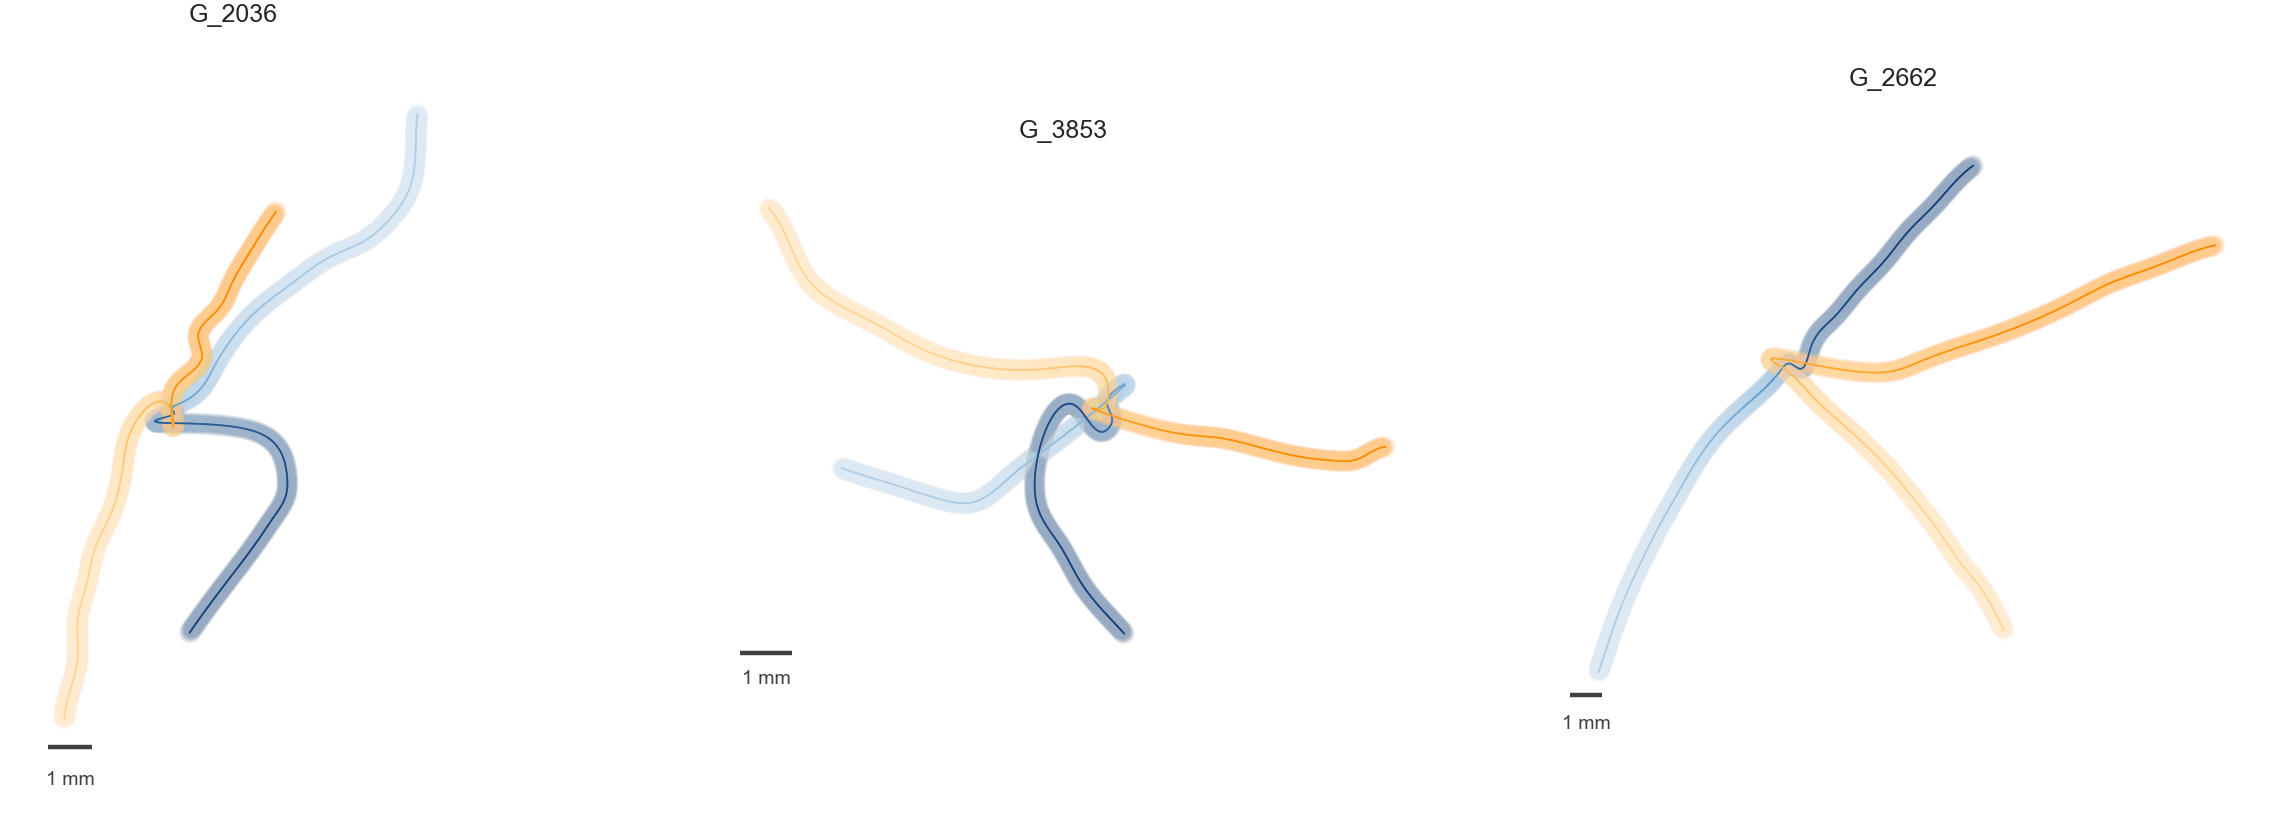

In [10]:
## SAME FIGURE, SMOOTHED PATH
## the head casts side to side, so away from contact the path is pulled toward a
## smoothed head/body blend -- but at the contact frames it is the raw head,
## so the point of contact is exactly where the data says it is

from scipy.interpolate import splprep, splev

CROP = {'G_3853': (2, 2)}   # interaction_id -> (frames off the front, frames off the end)

CONTACT_DIST = 1         # mm; frames under this are protected from smoothing
SMOOTH_WIN = 3           # frames, rolling mean of the head
BODY_MIX = 0.30          # 0 = smoothed head only, 1 = body only
CONTACT_SIGMA = 1.5      # frames; how quickly smoothing fades back in around contact
SPLINE_PTS = 600         # points along the fitted curve


def get_ex(iid):
    """interaction, cropped before anything else is computed"""
    ex = df[df['interaction_id'] == iid].sort_values('Frame')
    front, back = CROP.get(iid, (0, 0))
    return ex.iloc[front:len(ex) - back if back else None]


def smooth_path(ex, tr):
    """head path, de-cast away from contact, untouched at contact"""
    h = ex[[f'mm_Track_{tr} x_head', f'mm_Track_{tr} y_head']].values
    b = ex[[f'mm_Track_{tr} x_body', f'mm_Track_{tr} y_body']].values

    roll = lambda a: pd.DataFrame(a).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().values
    smooth = (1 - BODY_MIX) * roll(h) + BODY_MIX * roll(b)

    # weight 1 at contact frames, decaying with distance in frames
    contact = np.where(ex['min_distance'].values < CONTACT_DIST)[0]
    idx = np.arange(len(ex))
    if len(contact):
        gap = np.abs(idx[:, None] - contact[None, :]).min(axis=1)
        w = np.exp(-(gap ** 2) / (2 * CONTACT_SIGMA ** 2))[:, None]
    else:
        w = np.zeros((len(ex), 1))

    return w * h + (1 - w) * smooth


def spline(pts, n=SPLINE_PTS):
    """interpolating cubic through every point -- smooth curve, no points moved"""
    keep = np.r_[True, (np.diff(pts, axis=0) ** 2).sum(1) > 1e-12]
    pts = pts[keep]
    k = min(3, len(pts) - 1)
    tck, u = splprep(pts.T, s=0, k=k)
    ue = np.linspace(0, 1, n)
    xy = np.column_stack(splev(ue, tck))
    t = np.interp(ue, u, np.linspace(0, 1, len(pts)))
    return xy, t


def trace_smooth(ax, ex, tr):
    xy, t = spline(smooth_path(ex, tr))
    segs = np.stack([xy[:-1], xy[1:]], axis=1)
    cols = CMAPS[tr](ramp(t[:-1]))
    pale = lighten(cols)

    for w in np.linspace(HALO_W, CORE_LW * 1.5, N_HALO):
        ax.add_collection(LineCollection(segs, colors=pale, linewidths=w,
                                         alpha=HALO_ALPHA, capstyle='round',
                                         joinstyle='round', zorder=2))
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=CORE_LW,
                                     capstyle='round', joinstyle='round', zorder=3))
    ax.plot(xy[:, 0], xy[:, 1], alpha=0)


fig, axes = plt.subplots(1, len(IDS), figsize=(4.2 * len(IDS), 4.4))
axes = np.atleast_1d(axes)

for ax, iid in zip(axes, IDS):
    ex = get_ex(iid)
    for tr in (1, 2):
        trace_smooth(ax, ex, tr)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.margins(0.12)
    scale_bar(ax)
    ax.set_title(iid, fontsize=9, color='0.15', pad=6)

plt.tight_layout()
plt.show()


### CLUSTER 4 EXAMPLES

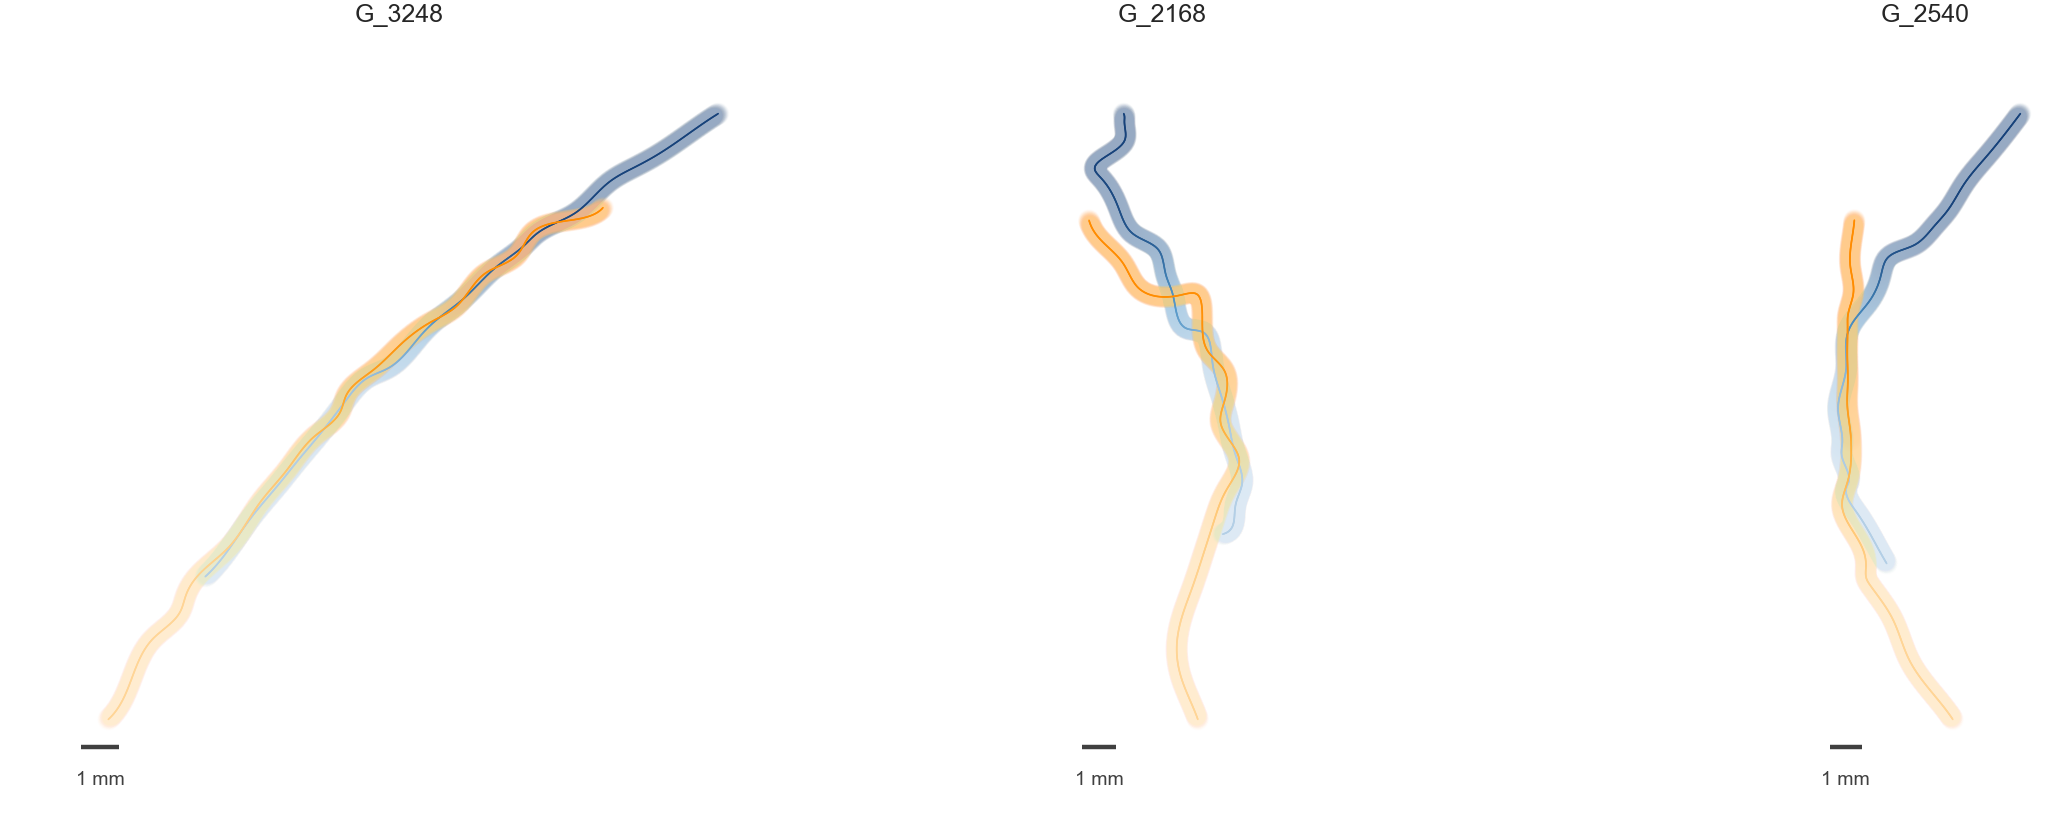

In [11]:
## CLUSTER 4 FIGURE TRACES -- same treatment as cluster 3

IDS_C4 = ['G_3248', 'G_2168', 'G_2540']
CROP_C4 = {}             # e.g. {'G_2168': (2, 2)} -> frames off the front / end


def get_ex_c4(iid):
    ex = df[df['interaction_id'] == iid].sort_values('Frame')
    front, back = CROP_C4.get(iid, (0, 0))
    return ex.iloc[front:len(ex) - back if back else None]


fig, axes = plt.subplots(1, len(IDS_C4), figsize=(4.2 * len(IDS_C4), 4.4))
axes = np.atleast_1d(axes)

for ax, iid in zip(axes, IDS_C4):
    ex = get_ex_c4(iid)
    for tr in (1, 2):
        trace_smooth(ax, ex, tr)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.margins(0.12)
    scale_bar(ax)
    ax.set_title(iid, fontsize=9, color='0.15', pad=6)

plt.tight_layout()
plt.show()


### CLUSTER 6 EXAMPLES

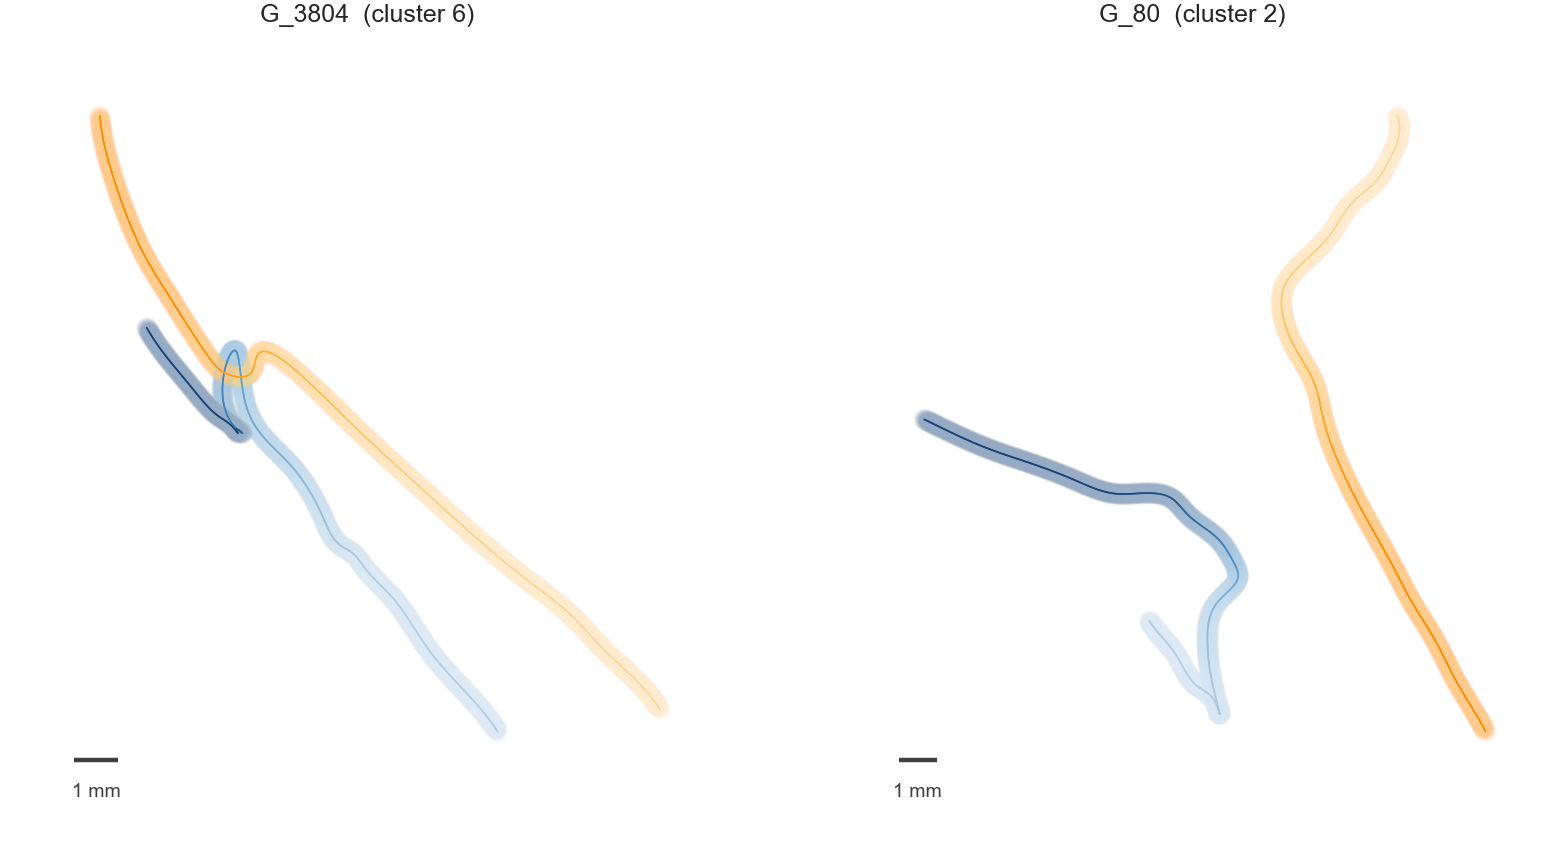

In [12]:
## FIGURE TRACES FOR THE LAST TWO -- same treatment

IDS_C6 = ['G_3804', 'G_80']
CROP_C6 = {}             # e.g. {'G_80': (2, 2)} -> frames off the front / end


def get_ex_c6(iid):
    ex = df[df['interaction_id'] == iid].sort_values('Frame')
    front, back = CROP_C6.get(iid, (0, 0))
    return ex.iloc[front:len(ex) - back if back else None]


fig, axes = plt.subplots(1, len(IDS_C6), figsize=(4.2 * len(IDS_C6), 4.4))
axes = np.atleast_1d(axes)

for ax, iid in zip(axes, IDS_C6):
    ex = get_ex_c6(iid)
    for tr in (1, 2):
        trace_smooth(ax, ex, tr)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.margins(0.12)
    scale_bar(ax)
    cl = ex['Yhat.idt.pca'].iloc[0]
    ax.set_title(f'{iid}  (cluster {cl})', fontsize=9, color='0.15', pad=6)

plt.tight_layout()
plt.show()


### ALL EXAMPLES

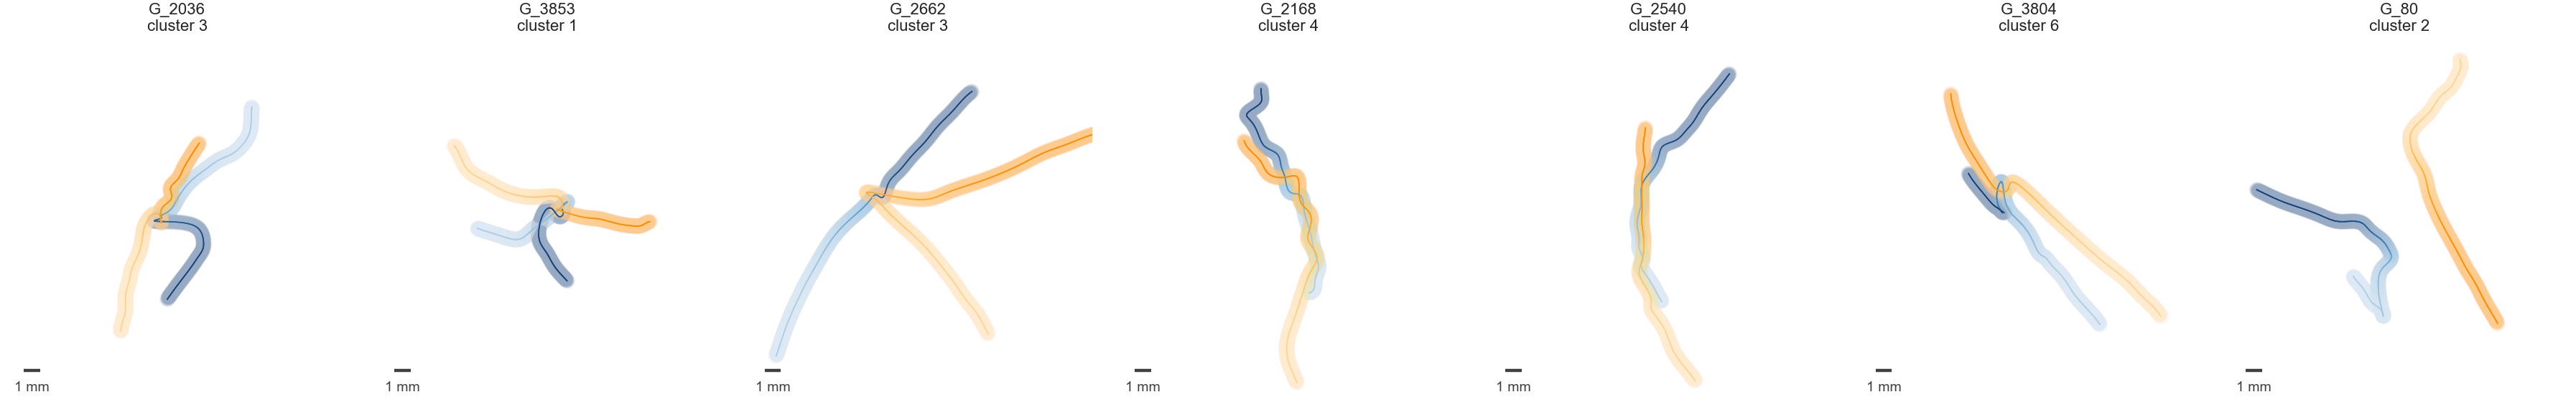

In [13]:
## ALL CHOSEN EXAMPLES SIDE BY SIDE, ON ONE COMMON SCALE

ALL_IDS = ['G_2036', 'G_3853', 'G_2662',        # cluster 3
           'G_2168', 'G_2540',                  # cluster 4
           'G_3804', 'G_80']                    # cluster 6
ALL_CROPS = {'G_3853': (2, 2)}
PAD_MM = 0.8             # breathing room around each trace
BAR_ON_EVERY_PANEL = True


def get_ex_any(iid):
    ex = df[df['interaction_id'] == iid].sort_values('Frame')
    front, back = ALL_CROPS.get(iid, (0, 0))
    return ex.iloc[front:len(ex) - back if back else None]


# every panel gets the same mm-per-inch, so the 1 mm bar is the same length throughout
exs = {iid: get_ex_any(iid) for iid in ALL_IDS}
paths = {iid: [smooth_path(ex, tr) for tr in (1, 2)] for iid, ex in exs.items()}
spans = []
for iid in ALL_IDS:
    pts = np.vstack(paths[iid])
    spans.append(max(pts[:, 0].ptp(), pts[:, 1].ptp()))
half = (max(spans) + 2 * PAD_MM) / 2

fig, axes = plt.subplots(1, len(ALL_IDS), figsize=(2.6 * len(ALL_IDS), 3.2))
axes = np.atleast_1d(axes)

for ax, iid in zip(axes, ALL_IDS):
    ex = exs[iid]
    for tr in (1, 2):
        trace_smooth(ax, ex, tr)

    pts = np.vstack(paths[iid])
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect('equal')
    ax.axis('off')

    if BAR_ON_EVERY_PANEL or ax is axes[0]:
        scale_bar(ax)

    cl = ex['Yhat.idt.pca'].iloc[0]
    ax.set_title(f'{iid}\ncluster {cl}', fontsize=8, color='0.15', pad=6)

plt.tight_layout()
plt.show()


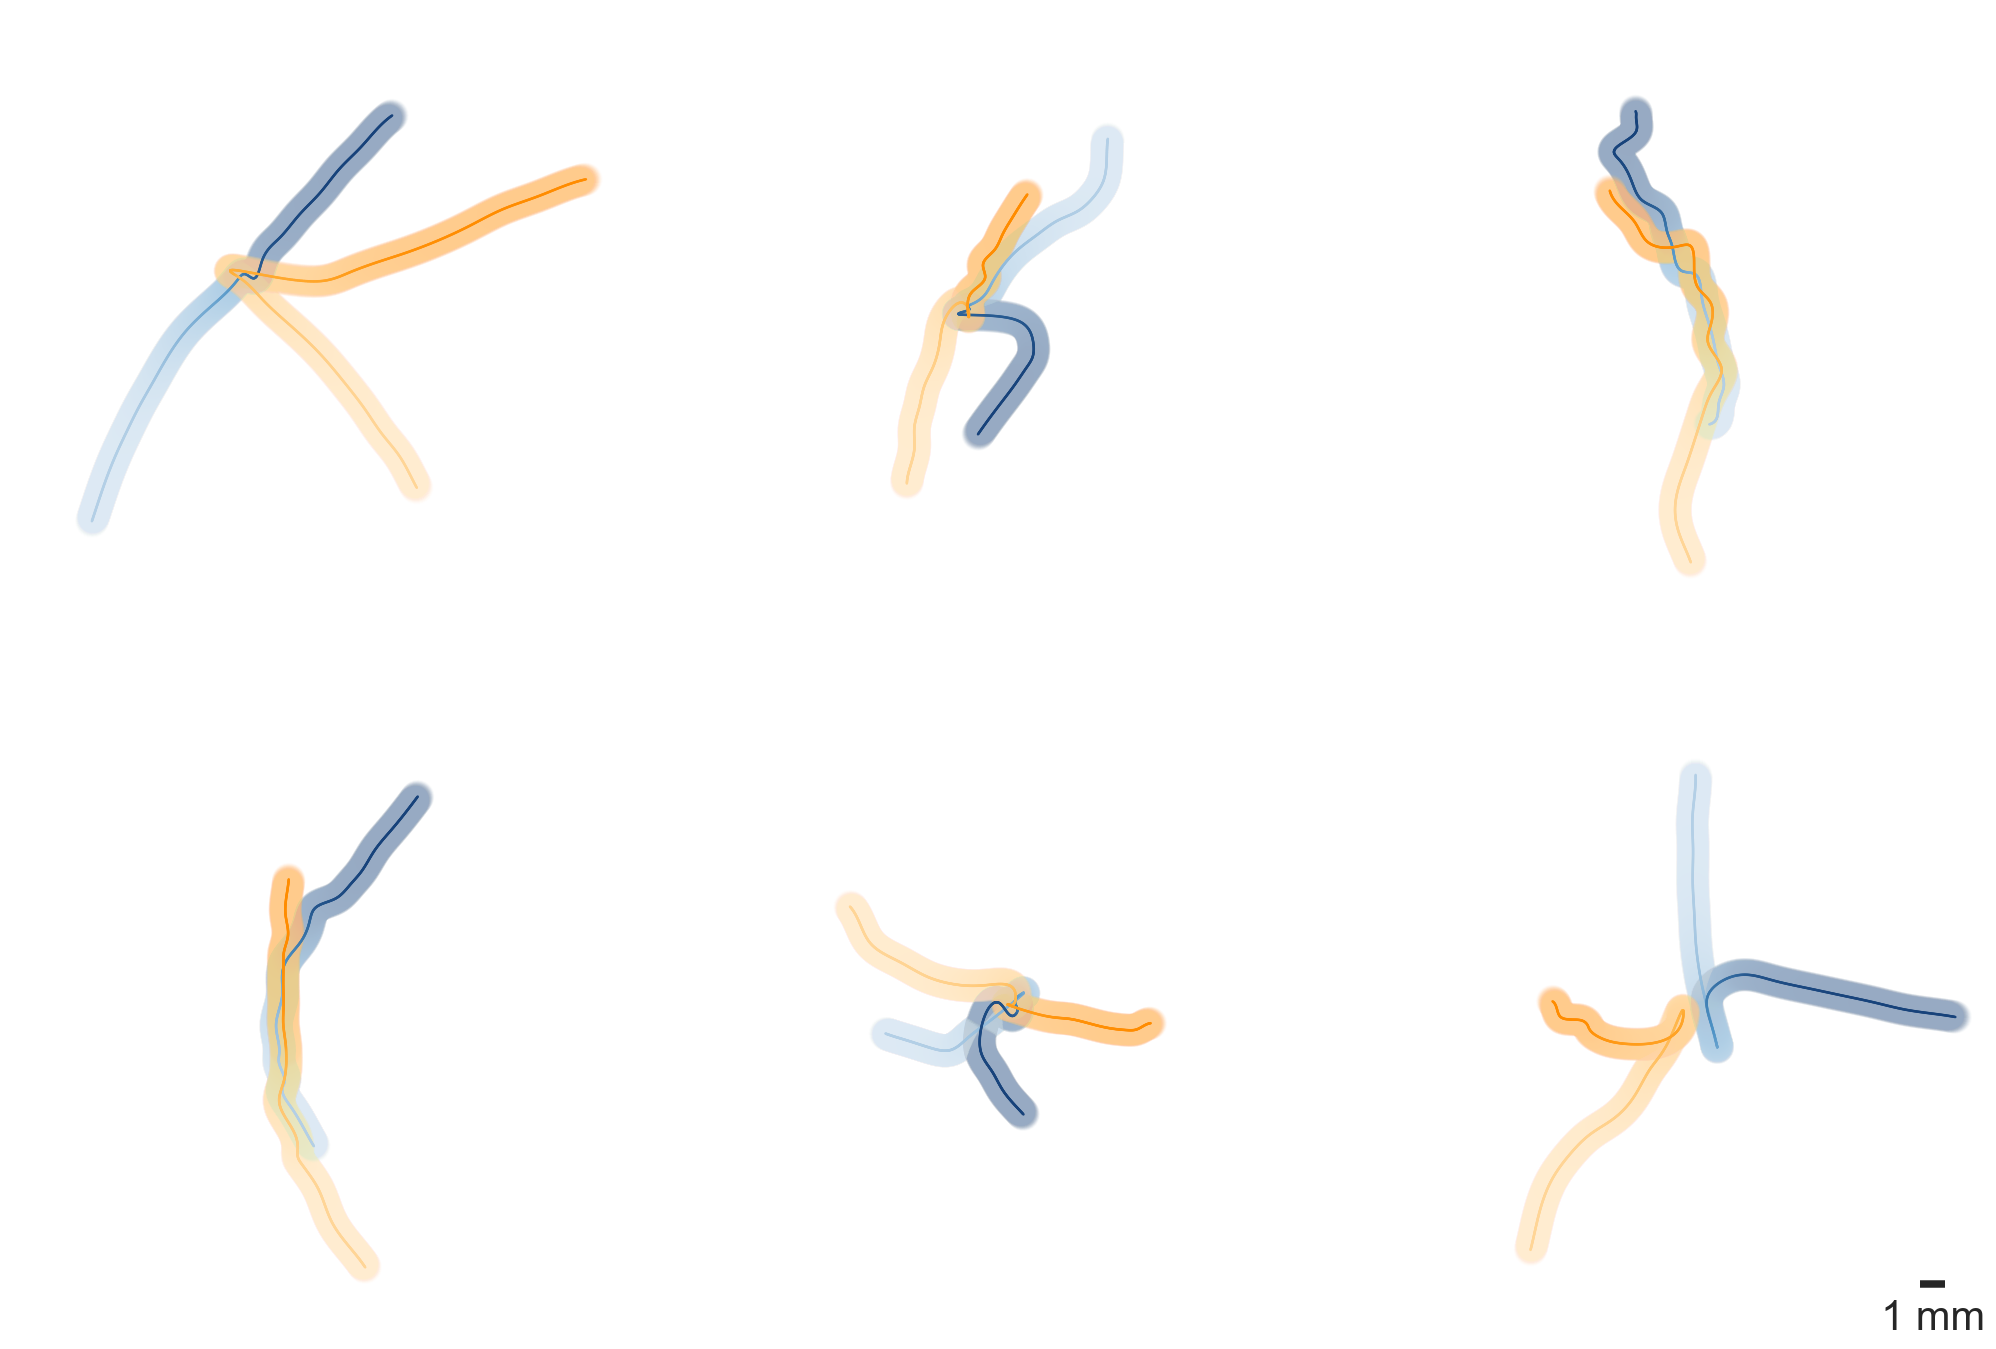

In [22]:
## FIGURE 1: SIX EXAMPLE INTERACTIONS, 2 x 3, ONE COMMON SCALE, SINGLE 1 mm BAR

%config InlineBackend.figure_format = 'retina'   # sharp preview in the notebook; the PDF was always vector

ALL_IDS = ['G_2662', 'G_2036', 'G_2168',
           'G_2540', 'G_3853', 'G_987']
CROPS = {'G_3853': (2, 2)}   # interaction_id -> (frames off the front, frames off the end)
NCOLS = 3
PAD_MM = 2               # breathing room around each trace
PANEL_IN = 1.2           # width of one panel, inches
PANEL_H_IN = 1.3
CORE_LW = 0.3            # trace weights halved with the panels, so it looks the same, just smaller
HALO_W = 4
OUT_STEM = '/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-1/example-interactions'
DPI = 600

mpl.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none',
                     'font.family': 'sans-serif', 'font.sans-serif': ['Arial'],
                     'figure.dpi': 300,
                     'savefig.dpi': DPI, 'savefig.bbox': 'tight',
                     'savefig.pad_inches': 0.02, 'savefig.transparent': True})


def get_ex_any(iid):
    ex = df[df['interaction_id'] == iid].sort_values('Frame')
    front, back = CROPS.get(iid, (0, 0))
    return ex.iloc[front:len(ex) - back if back else None]


def scale_bar_right(ax):
    """one 1 mm bar, bottom right of the panel it is drawn on"""
    MM = 1
    LW = 0.9
    COLOUR = '0.15'
    FONTSIZE = 5
    PAD_FRAC = 0.05      # inset from the right and bottom edges of the axes
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    bx = x1 - PAD_FRAC * (x1 - x0)
    by = y0 + PAD_FRAC * (y1 - y0)
    ax.plot([bx - MM, bx], [by, by], color=COLOUR, lw=LW,
            solid_capstyle='butt', zorder=4, clip_on=False)
    ax.text(bx - MM / 2, by - 0.025 * (y1 - y0), f'{MM} mm', ha='center', va='top',
            fontsize=FONTSIZE, color=COLOUR)


# every panel gets the same mm-per-inch, so the bar is true for all of them
exs = {iid: get_ex_any(iid) for iid in ALL_IDS}
paths = {iid: [smooth_path(ex, tr) for tr in (1, 2)] for iid, ex in exs.items()}
spans = []
for iid in ALL_IDS:
    pts = np.vstack(paths[iid])
    spans.append(max(np.ptp(pts[:, 0]), np.ptp(pts[:, 1])))
half = (max(spans) + 2 * PAD_MM) / 2

nrows = int(np.ceil(len(ALL_IDS) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS,
                         figsize=(PANEL_IN * NCOLS, PANEL_H_IN * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, iid in zip(axes, ALL_IDS):
    ex = exs[iid]
    for tr in (1, 2):
        trace_smooth(ax, ex, tr)

    pts = np.vstack(paths[iid])
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect('equal')
    ax.axis('off')

for ax in axes[len(ALL_IDS):]:
    ax.axis('off')

scale_bar_right(axes[len(ALL_IDS) - 1])

plt.tight_layout()
fig.savefig(f'{OUT_STEM}.pdf')     

plt.show()


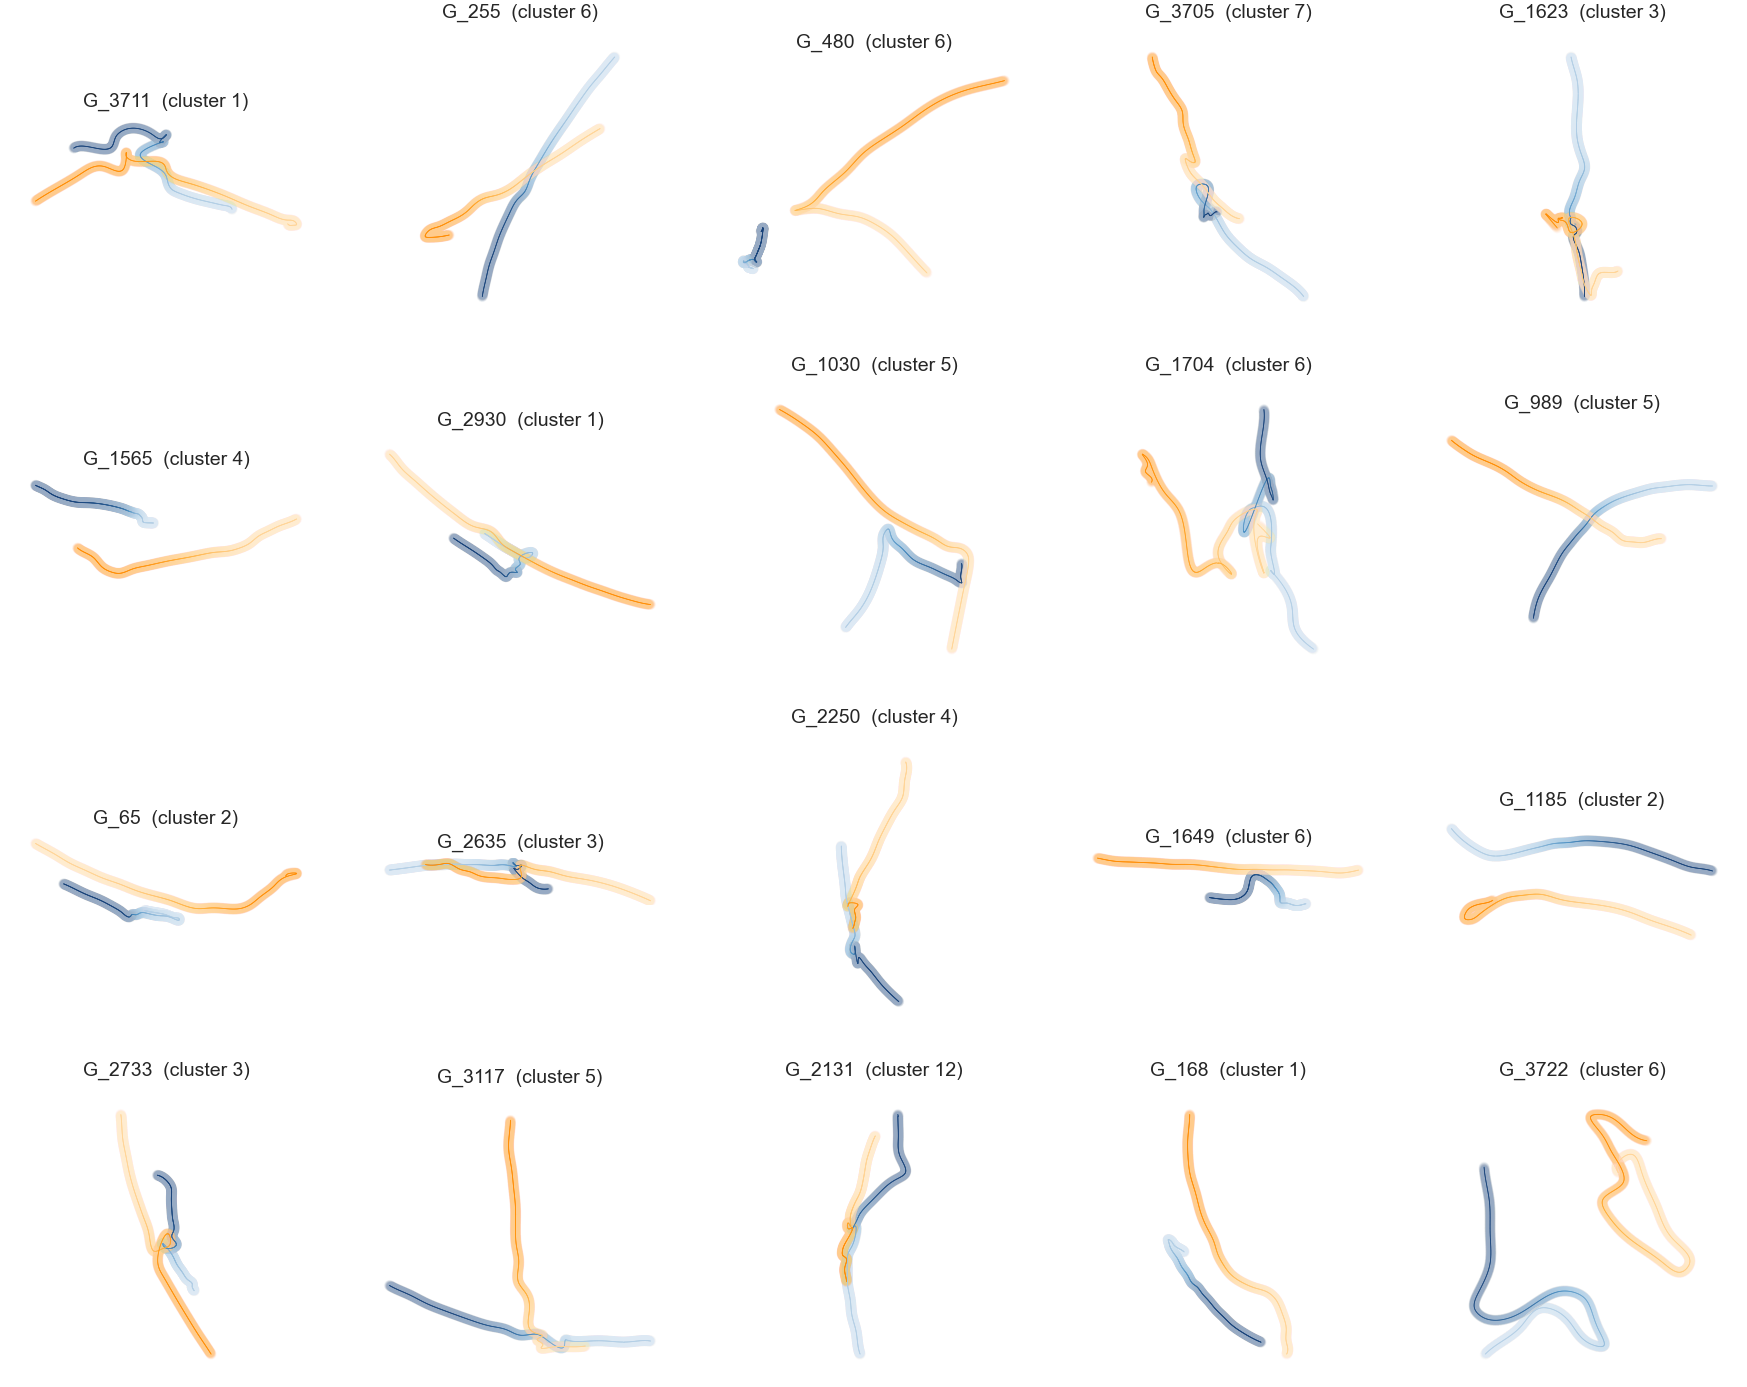

['G_3711', 'G_255', 'G_480', 'G_3705', 'G_1623', 'G_1565', 'G_2930', 'G_1030', 'G_1704', 'G_989', 'G_65', 'G_2635', 'G_2250', 'G_1649', 'G_1185', 'G_2733', 'G_3117', 'G_2131', 'G_168', 'G_3722']


In [20]:
## SCRATCH: RANDOM G INTERACTIONS TO BROWSE FOR A REPLACEMENT -- delete when done

N_SHOW = 20              # how many to draw
NCOLS = 5
SEED = None              # put a number here to freeze the draw, None = new set every run
PANEL_IN = 1.8
EXCLUDE = ALL_IDS        # the six already in the figure

pool = df[df['interaction_id'].str.startswith('G_')]['interaction_id'].unique()
pool = np.array([i for i in pool if i not in EXCLUDE])

rng = np.random.default_rng(SEED)
pick = rng.choice(pool, size=min(N_SHOW, len(pool)), replace=False)

nrows = int(np.ceil(len(pick) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(PANEL_IN * NCOLS, PANEL_IN * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, iid in zip(axes, pick):
    ex = df[df['interaction_id'] == iid].sort_values('Frame')
    for tr in (1, 2):
        trace_smooth(ax, ex, tr)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.margins(0.12)
    cl = ex['Yhat.idt.pca'].iloc[0]
    ax.set_title(f'{iid}  (cluster {cl})', fontsize=7, color='0.15', pad=4)

for ax in axes[len(pick):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

print(list(pick))
